<a href="https://colab.research.google.com/github/6hamuge/Beyond-Sleep-Prediction/blob/main/PTDT_Sleep_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌙 PTDT: Personalized Temporal Deviation Transformer
## 라이프로그 기반 수면·감정·스트레스 예측

---

### 📌 예측 대상 (7개 이진 레이블)

| 레이블 | 설명 | 기준 |
|--------|------|------|
| **Q1** | 기상 직후 수면의 질 | 0: 개인 평균 이하, 1: 개인 평균 이상 |
| **Q2** | 취침 전 신체 피로도 | 0: 피로 높음, 1: 피로 낮음 |
| **Q3** | 취침 전 스트레스 | 0: 스트레스 높음, 1: 스트레스 낮음 |
| **S1** | 총 수면시간 (TST) 권장 충족 | 0: 미충족, 1: 충족 |
| **S2** | 수면 효율 (SE) 권장 충족 | 0: 미충족, 1: 충족 |
| **S3** | 수면 시작 지연시간 (SOL) | 0: 미충족, 1: 충족 |
| **S4** | 수면 중 각성시간 (WASO) | 0: 미충족, 1: 충족 |

### 🏗️ 핵심 아이디어
- **개인화**: 각 레이블이 개인 내 편차 기반이므로 → `z-score` 정규화를 **피험자 단위**로 수행
- **편차 임베딩**: 절대값이 아닌 `(오늘 - 개인 rolling mean) / 개인 rolling std` 를 모델 입력으로
- **Multi-Task**: 7개 레이블을 단일 공유 인코더 + 7개 분류 헤드로 동시 예측
- **LOSO-CV**: Leave-One-Subject-Out Cross-Validation (10명 소규모 데이터 대응)

## 0. 환경 설정 및 패키지 설치

In [ ]:
# Google Colab 환경 확인
import sys
IN_COLAB = 'google.colab' in sys.modules
print(f'Colab 환경: {IN_COLAB}')

# 필수 패키지 설치
!pip install pyarrow pandas numpy scikit-learn torch -q
!pip install matplotlib seaborn tqdm -q

print('✅ 패키지 설치 완료')

Colab 환경: True
✅ 패키지 설치 완료


## 1. 데이터 업로드

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/ch2025/'
print(f'✅ Drive 마운트 완료. DATA_DIR = {DATA_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive 마운트 완료. DATA_DIR = /content/drive/MyDrive/ch2025/


## 2. 데이터 로딩 및 구조 탐색

In [ ]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

FILE_MAP = {
    'ac_status'   : 'ch2025_mACStatus.parquet',
    'activity'    : 'ch2025_mActivity.parquet',
    'ambience'    : 'ch2025_mAmbience.parquet',
    'ble'         : 'ch2025_mBle.parquet',
    'gps'         : 'ch2025_mGps.parquet',
    'light'       : 'ch2025_mLight.parquet',
    'screen'      : 'ch2025_mScreenStatus.parquet',
    'usage_stats' : 'ch2025_mUsageStats.parquet',
    'wifi'        : 'ch2025_mWifi.parquet',
    'hr'          : 'ch2025_wHr.parquet',
    'w_light'     : 'ch2025_wLight.parquet',
    'pedo'        : 'ch2025_wPedo.parquet',
}

# ─── 데이터 로드 ───────────────────────────────────────────
raw = {}
for key, fname in FILE_MAP.items():
    path = os.path.join(DATA_DIR+"ch2025_data_items/", fname)
    if os.path.exists(path):
        raw[key] = pd.read_parquet(path)
        print(f'✅ {key:12s}: {raw[key].shape}  | cols: {list(raw[key].columns)}')
    else:
        print(f'❌ {key}: 파일 없음 ({path})')

print(f'\n📊 로드된 테이블: {len(raw)}개')

✅ ac_status   : (939896, 3)  | cols: ['subject_id', 'timestamp', 'm_charging']
✅ activity    : (961062, 3)  | cols: ['subject_id', 'timestamp', 'm_activity']
✅ ambience    : (476577, 3)  | cols: ['subject_id', 'timestamp', 'm_ambience']
✅ ble         : (21830, 3)  | cols: ['subject_id', 'timestamp', 'm_ble']
✅ gps         : (800611, 3)  | cols: ['subject_id', 'timestamp', 'm_gps']
✅ light       : (96258, 3)  | cols: ['subject_id', 'timestamp', 'm_light']
✅ screen      : (939653, 3)  | cols: ['subject_id', 'timestamp', 'm_screen_use']
✅ usage_stats : (45197, 3)  | cols: ['subject_id', 'timestamp', 'm_usage_stats']
✅ wifi        : (76336, 3)  | cols: ['subject_id', 'timestamp', 'm_wifi']
✅ hr          : (382918, 3)  | cols: ['subject_id', 'timestamp', 'heart_rate']
✅ w_light     : (633741, 3)  | cols: ['subject_id', 'timestamp', 'w_light']
✅ pedo        : (748100, 9)  | cols: ['subject_id', 'timestamp', 'step', 'step_frequency', 'running_step', 'walking_step', 'distance', 'speed', 'burne

In [ ]:
# ─── 각 테이블 샘플 확인 ──────────────────────────────────
for key in list(raw.keys())[:3]:
    print(f'\n{'='*50}')
    print(f'[{key}]')
    display(raw[key].head(3))
    print(raw[key].dtypes)


[ac_status]


,subject_id,timestamp,m_charging
0,id01,2024-06-26 12:03:00,0
1,id01,2024-06-26 12:04:00,0
2,id01,2024-06-26 12:05:00,0


subject_id            object
timestamp     datetime64[ns]
m_charging             int64
dtype: object

[activity]


,subject_id,timestamp,m_activity
0,id01,2024-06-26 12:03:00,4
1,id01,2024-06-26 12:04:00,0
2,id01,2024-06-26 12:05:00,0


subject_id            object
timestamp     datetime64[ns]
m_activity             int64
dtype: object

[ambience]


,subject_id,timestamp,m_ambience
0,id01,2024-06-26 13:00:10,"[[Music, 0.30902618], [Vehicle, 0.081680894], ..."
1,id01,2024-06-26 13:02:10,"[[Music, 0.62307084], [Vehicle, 0.021118319], ..."
2,id01,2024-06-26 13:04:10,"[[Horse, 0.25209898], [Animal, 0.24263993], [C..."


subject_id            object
timestamp     datetime64[ns]
m_ambience            object
dtype: object


## 3. 라벨(Label) 데이터 설정

In [ ]:
# ─── 레이블 파일 업로드 ────────────────────────────────────
# 레이블 CSV 예시 컬럼: subject_id, date, Q1, Q2, Q3, S1, S2, S3, S4

# 방법 1: 파일이 있는 경우
LABEL_PATH = os.path.join(DATA_DIR, 'ch2026_metrics_train.csv')  # 경로 수정

if os.path.exists(LABEL_PATH):
    labels_df = pd.read_csv(LABEL_PATH)
    print(f'✅ 레이블 로드: {labels_df.shape}')
    display(labels_df.head())
else:
    # 방법 2: 레이블 파일이 없을 경우 → 센서 데이터에 포함된 경우 처리
    print('⚠️  레이블 파일을 찾지 못했습니다.')
    print('   센서 데이터 내 레이블 컬럼을 확인합니다...')

    # 각 테이블에서 레이블 관련 컬럼 탐색
    TARGET_COLS = ['Q1', 'Q2', 'Q3', 'S1', 'S2', 'S3', 'S4']
    for key, df in raw.items():
        found = [c for c in df.columns if c in TARGET_COLS or
                 any(t.lower() in c.lower() for t in TARGET_COLS)]
        if found:
            print(f'  [{key}]: {found}')

LABEL_COLS = ['Q1', 'Q2', 'Q3', 'S1', 'S2', 'S3', 'S4']

✅ 레이블 로드: (450, 10)


,subject_id,sleep_date,lifelog_date,Q1,Q2,Q3,S1,S2,S3,S4
0,id01,2024-06-27,2024-06-26,0,0,0,0,0,1,0
1,id01,2024-06-28,2024-06-27,0,0,0,0,1,1,1
2,id01,2024-06-29,2024-06-28,1,0,0,1,1,1,1
3,id01,2024-06-30,2024-06-29,1,0,1,1,0,0,0
4,id01,2024-07-01,2024-06-30,0,1,1,1,1,1,1


## 4. 피처 엔지니어링 (일별 집계)

각 센서의 원시 시계열 → **하루 단위 통계 특징**으로 변환  
핵심: `subject_id + date` 기준 집계

In [ ]:
# ─── 유틸리티 함수 ────────────────────────────────────────

def get_timestamp_col(df):
    """타임스탬프 컬럼 자동 탐지"""
    candidates = ['timestamp', 'time', 'datetime', 'ts', 'date']
    for c in df.columns:
        if any(k in c.lower() for k in candidates):
            return c
    # datetime dtype으로 탐지
    for c in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[c]):
            return c
    return None


def extract_daily_features(df, sensor_name, ts_col=None, subject_col='subject_id'):
    """
    센서 데이터프레임 → 하루 단위 집계 피처 반환

    집계 통계: mean, std, min, max, count
    """
    df = df.copy()

    # 타임스탬프 처리
    if ts_col is None:
        ts_col = get_timestamp_col(df)

    if ts_col and ts_col in df.columns:
        df[ts_col] = pd.to_datetime(df[ts_col], unit='ms', errors='coerce') \
                     if df[ts_col].dtype in ['int64','float64'] \
                     else pd.to_datetime(df[ts_col], errors='coerce')
        df['date'] = df[ts_col].dt.date
    elif 'date' not in df.columns:
        print(f'  ⚠️  [{sensor_name}] 타임스탬프 컬럼을 찾지 못했습니다.')
        return None

    df['date'] = pd.to_datetime(df['date'])

    # 수치형 컬럼만 선택 (subject_id, date 제외)
    exclude = {subject_col, 'date', ts_col}
    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in exclude]

    if not num_cols:
        print(f'  ⚠️  [{sensor_name}] 수치형 컬럼이 없습니다.')
        return None

    # 하루 단위 집계
    grp = df.groupby([subject_col, 'date'])[num_cols]
    aggs = {
        'mean' : grp.mean(),
        'std'  : grp.std().fillna(0),
        'min'  : grp.min(),
        'max'  : grp.max(),
        'count': grp.count(),
    }

    # 멀티-집계 컬럼 병합
    result_parts = []
    for agg_name, agg_df in aggs.items():
        agg_df.columns = [f'{sensor_name}__{c}__{agg_name}' for c in agg_df.columns]
        result_parts.append(agg_df)

    result = pd.concat(result_parts, axis=1).reset_index()
    print(f'  ✅ [{sensor_name}]: {result.shape[1]-2}개 피처, {result.shape[0]}행')
    return result


print('🔧 피처 엔지니어링 함수 정의 완료')

🔧 피처 엔지니어링 함수 정의 완료


In [ ]:
# ─── 모든 센서 → 일별 피처 추출 ──────────────────────────
print('📊 일별 피처 추출 시작...')

daily_features = {}
for key, df in raw.items():
    feat = extract_daily_features(df, sensor_name=key)
    if feat is not None:
        daily_features[key] = feat

print(f'\n✅ 피처 추출 완료: {len(daily_features)}개 센서')

📊 일별 피처 추출 시작...
  ✅ [ac_status]: 5개 피처, 700행
  ✅ [activity]: 5개 피처, 700행
  ⚠️  [ambience] 수치형 컬럼이 없습니다.
  ⚠️  [ble] 수치형 컬럼이 없습니다.
  ⚠️  [gps] 수치형 컬럼이 없습니다.
  ✅ [light]: 5개 피처, 700행
  ✅ [screen]: 5개 피처, 700행
  ⚠️  [usage_stats] 수치형 컬럼이 없습니다.
  ⚠️  [wifi] 수치형 컬럼이 없습니다.
  ⚠️  [hr] 수치형 컬럼이 없습니다.
  ✅ [w_light]: 5개 피처, 664행
  ✅ [pedo]: 35개 피처, 653행

✅ 피처 추출 완료: 6개 센서


In [ ]:
# ─── 모든 센서 피처 통합 (subject_id + date 기준 merge) ──
from functools import reduce

dfs = list(daily_features.values())

if len(dfs) == 0:
    raise RuntimeError('추출된 피처가 없습니다. 데이터 로딩을 확인하세요.')

feature_df = reduce(
    lambda left, right: pd.merge(left, right, on=['subject_id', 'date'], how='outer'),
    dfs
)

print(f'✅ 통합 피처 데이터프레임: {feature_df.shape}')
print(f'   - 피험자 수: {feature_df["subject_id"].nunique()}')
print(f'   - 날짜 범위: {feature_df["date"].min()} ~ {feature_df["date"].max()}')
print(f'   - 총 피처 수: {feature_df.shape[1] - 2}')
display(feature_df.head(3))

✅ 통합 피처 데이터프레임: (700, 62)
   - 피험자 수: 10
   - 날짜 범위: 2024-06-03 00:00:00 ~ 2024-11-19 00:00:00
   - 총 피처 수: 60


,subject_id,date,ac_status__m_charging__mean,ac_status__m_charging__std,ac_status__m_charging__min,ac_status__m_charging__max,ac_status__m_charging__count,activity__m_activity__mean,activity__m_activity__std,activity__m_activity__min,...,pedo__distance__max,pedo__speed__max,pedo__burned_calories__max,pedo__step__count,pedo__step_frequency__count,pedo__running_step__count,pedo__walking_step__count,pedo__distance__count,pedo__speed__count,pedo__burned_calories__count
0,id01,2024-06-26,0.215859,0.411719,0,1,681,2.953586,1.409959,0,...,95.293213,1.588220,54.240009,643.0,643.0,643.0,643.0,643.0,643.0,643.0
1,id01,2024-06-27,0.158571,0.365406,0,1,1400,2.867361,1.366650,0,...,77.439941,1.290666,105.160110,1345.0,1345.0,1345.0,1345.0,1345.0,1345.0,1345.0
2,id01,2024-06-28,0.180282,0.384557,0,1,1420,2.763889,1.164008,0,...,101.530029,1.692167,4.110079,1358.0,1358.0,1358.0,1358.0,1358.0,1358.0,1358.0


## 5. 레이블 병합 및 개인화 편차 피처 생성

핵심: **Rolling Baseline** → 개인별 `z-score` 편차값 생성

In [ ]:
if 'labels_df' in dir() and labels_df is not None:
    labels_df['date'] = pd.to_datetime(labels_df['lifelog_date']) # Changed 'date' to 'lifelog_date'
    full_df = pd.merge(feature_df, labels_df[['subject_id', 'date'] + LABEL_COLS],
                       on=['subject_id', 'date'], how='inner')
    print(f'✅ 레이블 병합 후: {full_df.shape}')
    print(f'   레이블 분포:')
    for lc in LABEL_COLS:
        if lc in full_df.columns:
            vc = full_df[lc].value_counts()
            print(f'   {lc}: {dict(vc)}')
else:
    # 레이블이 아직 없는 경우 피처만으로 진행
    full_df = feature_df.copy()
    print('⚠️  레이블 없이 피처 데이터만 준비됨. 레이블 로드 후 병합 필요.')

✅ 레이블 병합 후: (450, 69)
   레이블 분포:
   Q1: {0: np.int64(227), 1: np.int64(223)}
   Q2: {1: np.int64(253), 0: np.int64(197)}
   Q3: {1: np.int64(270), 0: np.int64(180)}
   S1: {1: np.int64(307), 0: np.int64(143)}
   S2: {1: np.int64(293), 0: np.int64(157)}
   S3: {1: np.int64(298), 0: np.int64(152)}
   S4: {1: np.int64(252), 0: np.int64(198)}


In [ ]:
# ─── 개인화 편차 피처 (Personalized Deviation Features) ───
# 핵심 아이디어: 절대값이 아닌 "개인 평균 대비 편차"를 모델에 입력

ROLLING_WINDOW = 7  # 7일 rolling window (조정 가능)

feat_cols = [c for c in full_df.columns
             if c not in ['subject_id', 'date'] + LABEL_COLS]

print(f'피처 컬럼 수: {len(feat_cols)}')
print(f'Rolling window: {ROLLING_WINDOW}일')

deviation_dfs = []

for subj_id, subj_df in full_df.groupby('subject_id'):
    subj_df = subj_df.sort_values('date').copy()

    # 수치형 피처만
    num_feat = subj_df[feat_cols].select_dtypes(include=[np.number]).columns.tolist()

    # Rolling 통계 (shift(1): 오늘 데이터 누수 방지)
    rolling_mean = subj_df[num_feat].shift(1).rolling(window=ROLLING_WINDOW, min_periods=1).mean()
    rolling_std  = subj_df[num_feat].shift(1).rolling(window=ROLLING_WINDOW, min_periods=1).std().fillna(1e-6)
    rolling_std  = rolling_std.replace(0, 1e-6)  # 0 나누기 방지

    # z-score 편차
    deviation = (subj_df[num_feat] - rolling_mean) / rolling_std
    deviation.columns = [f'dev__{c}' for c in deviation.columns]

    # 원본 + 편차 결합
    result = pd.concat([
        subj_df[['subject_id', 'date'] + LABEL_COLS].reset_index(drop=True),
        subj_df[num_feat].reset_index(drop=True),
        deviation.reset_index(drop=True)
    ], axis=1)
    deviation_dfs.append(result)

full_dev_df = pd.concat(deviation_dfs, ignore_index=True)

# Rolling window 초기 NaN 제거
full_dev_df = full_dev_df.dropna(subset=feat_cols[:5])  # 일부 피처 기준

print(f'\n✅ 편차 피처 생성 완료: {full_dev_df.shape}')
print(f'   원본 피처: {len(num_feat)}개')
print(f'   편차 피처: {len(num_feat)}개')
print(f'   총 피처: {len(num_feat)*2}개')

피처 컬럼 수: 60
Rolling window: 7일

✅ 편차 피처 생성 완료: (450, 129)
   원본 피처: 60개
   편차 피처: 60개
   총 피처: 120개


## 6. 시퀀스 데이터셋 구성

각 샘플 = 과거 `SEQ_LEN`일의 피처 시퀀스 → 다음 날 레이블 예측

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

SEQ_LEN = 7   # 과거 7일을 보고 당일 예측 (조정 가능: 3, 5, 7, 14)


class LifelogDataset(Dataset):
    """
    subject_id별 시계열 슬라이딩 윈도우 데이터셋

    X: (SEQ_LEN, n_features) — 과거 SEQ_LEN일의 피처
    y: (7,) — 당일 Q1,Q2,Q3,S1,S2,S3,S4 레이블
    """

    def __init__(self, df, feat_cols, label_cols, seq_len=7,
                 exclude_subjects=None):
        self.seq_len = seq_len
        self.feat_cols = feat_cols
        self.label_cols = label_cols
        self.samples = []

        subjects = df['subject_id'].unique()
        if exclude_subjects:
            subjects = [s for s in subjects if s not in exclude_subjects]

        for subj in subjects:
            subj_df = df[df['subject_id'] == subj].sort_values('date')

            X_arr = subj_df[feat_cols].values.astype(np.float32)

            # 레이블 존재 여부 확인
            avail_labels = [lc for lc in label_cols if lc in subj_df.columns]
            if avail_labels:
                y_arr = subj_df[avail_labels].values.astype(np.float32)
            else:
                y_arr = np.zeros((len(subj_df), len(label_cols)), dtype=np.float32)

            # NaN 처리: 피처는 0으로, 레이블은 -1로 마킹
            X_arr = np.nan_to_num(X_arr, nan=0.0, posinf=0.0, neginf=0.0)
            # 클리핑: 극단값 제거
            X_arr = np.clip(X_arr, -10, 10)

            # 슬라이딩 윈도우 샘플 생성
            for i in range(seq_len, len(subj_df)):
                x_seq = X_arr[i-seq_len:i]   # (seq_len, n_feat)
                y_lbl = y_arr[i]              # (n_labels,)

                # 레이블에 NaN이 없는 경우만 포함
                if not np.any(np.isnan(y_lbl)):
                    self.samples.append((
                        torch.tensor(x_seq, dtype=torch.float32),
                        torch.tensor(y_lbl, dtype=torch.float32),
                        subj
                    ))

        print(f'  Dataset: {len(self.samples)}개 샘플 '
              f'(subject={len(subjects)}명, seq_len={seq_len})')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y, subj = self.samples[idx]
        return x, y


# 피처 컬럼 선택: 원본 + 편차 모두 사용
all_feat_cols = (
    [c for c in full_dev_df.columns if c not in ['subject_id','date']+LABEL_COLS]
)

# 레이블이 있는 컬럼만 사용
available_labels = [lc for lc in LABEL_COLS if lc in full_dev_df.columns]
if not available_labels:
    print('⚠️  레이블이 없습니다. 레이블 데이터를 병합하세요.')
    available_labels = LABEL_COLS  # 테스트용 더미

N_FEATURES = len(all_feat_cols)
N_LABELS   = len(available_labels)

print(f'입력 피처 수: {N_FEATURES}')
print(f'레이블 수: {N_LABELS} ({available_labels})')

입력 피처 수: 120
레이블 수: 7 (['Q1', 'Q2', 'Q3', 'S1', 'S2', 'S3', 'S4'])


## 7. PTDT 모델 아키텍처

```
입력 (SEQ_LEN, N_FEATURES)
   ↓
Linear Projection → (SEQ_LEN, d_model)
   ↓
Positional Encoding
   ↓
Transformer Encoder (L layers)
   ↓
CLS Token Pooling
   ↓
7개 분류 헤드 (Q1, Q2, Q3, S1, S2, S3, S4)
```

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math


class PositionalEncoding(nn.Module):
    """사인/코사인 위치 인코딩"""

    def __init__(self, d_model, max_len=365, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class DeviationAwareAttention(nn.Module):
    """
    편차 인식 어텐션 (Deviation-Aware Attention)

    편차 피처와 원본 피처를 별도 처리 후 융합
    """

    def __init__(self, d_model, n_heads, n_raw_feat, n_dev_feat):
        super().__init__()
        self.n_raw_feat = n_raw_feat
        self.n_dev_feat = n_dev_feat

        # 원본 피처 인코더
        self.raw_proj = nn.Linear(n_raw_feat, d_model) # Changed from d_model // 2 to d_model
        # 편차 피처 인코더
        self.dev_proj = nn.Linear(n_dev_feat, d_model) # Changed from d_model // 2 to d_model
        # 융합 레이어
        self.fusion = nn.Linear(2 * d_model, d_model) # Changed from d_model to 2 * d_model
        # Multi-Head Attention
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, raw_feat, dev_feat):
        # raw_feat: (B, T, n_raw_feat), dev_feat: (B, T, n_dev_feat)
        raw_emb = F.gelu(self.raw_proj(raw_feat))  # (B, T, d_model)
        dev_emb = F.gelu(self.dev_proj(dev_feat))  # (B, T, d_model)

        # 편차 피처를 쿼리로, 원본 피처를 키/밸류로 — 편차 중심 어텐션
        fused = self.fusion(torch.cat([raw_emb, dev_emb], dim=-1))
        attn_out, _ = self.attn(dev_emb, raw_emb, raw_emb)  # Q=dev, K=raw, V=raw
        return self.norm(fused + attn_out)


class PTDTransformer(nn.Module):
    """
    Personalized Temporal Deviation Transformer

    Args:
        n_features  : 총 입력 피처 수 (원본 + 편차)
        n_labels    : 예측 레이블 수 (7)
        d_model     : Transformer 임베딩 차원
        n_heads     : Multi-head attention 헤드 수
        n_layers    : Transformer 인코더 레이어 수
        d_ff        : Feed-forward 히든 차원
        dropout     : Dropout 비율
        seq_len     : 입력 시퀀스 길이
    """

    def __init__(self, n_features, n_labels=7, d_model=64,
                 n_heads=4, n_layers=2, d_ff=128,
                 dropout=0.1, seq_len=7):
        super().__init__()

        # 원본 / 편차 피처 분리 (절반씩)
        self.n_raw = n_features // 2
        self.n_dev = n_features - self.n_raw

        # ── 편차 인식 어텐션 입력 레이어 ──────────────────
        self.dev_attn = DeviationAwareAttention(
            d_model, n_heads, self.n_raw, self.n_dev
        )

        # ── CLS 토큰 (분류용 전역 표현) ──────────────────
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

        # ── 위치 인코딩 ───────────────────────────────────
        self.pos_enc = PositionalEncoding(d_model, max_len=seq_len+1, dropout=dropout)

        # ── Transformer 인코더 ────────────────────────────
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        # ── Multi-Task 분류 헤드 ──────────────────────────
        # 공유 표현
        self.shared_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.LayerNorm(d_model)
        )
        # 레이블별 개별 헤드
        self.task_heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(d_model, 32),
                nn.GELU(),
                nn.Linear(32, 1)  # BCE용 logit
            )
            for _ in range(n_labels)
        ])

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        """
        x: (batch, seq_len, n_features)
        returns: (batch, n_labels) — 각 레이블의 logit
        """
        B, T, _ = x.shape

        # 원본 / 편차 분리
        raw = x[:, :, :self.n_raw]
        dev = x[:, :, self.n_raw:]

        # 편차 인식 임베딩
        emb = self.dev_attn(raw, dev)  # (B, T, d_model)

        # CLS 토큰 prepend
        cls = self.cls_token.expand(B, -1, -1)  # (B, 1, d_model)
        emb = torch.cat([cls, emb], dim=1)       # (B, T+1, d_model)

        # 위치 인코딩
        emb = self.pos_enc(emb)

        # Transformer 인코더
        enc = self.transformer(emb)  # (B, T+1, d_model)

        # CLS 토큰 추출 (전역 표현)
        cls_out = enc[:, 0, :]  # (B, d_model)

        # 공유 헤드
        shared = self.shared_head(cls_out)  # (B, d_model)

        # 각 태스크 헤드
        logits = torch.cat(
            [head(shared) for head in self.task_heads], dim=-1
        )  # (B, n_labels)

        return logits


# ── 모델 생성 및 구조 확인 ────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')

model = PTDTransformer(
    n_features = N_FEATURES,
    n_labels   = N_LABELS,
    d_model    = 64,
    n_heads    = 4,
    n_layers   = 2,
    d_ff       = 128,
    dropout    = 0.1,
    seq_len    = SEQ_LEN
).to(device)

# 파라미터 수
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n모델 파라미터: {total_params:,} (학습 가능: {train_params:,})')

# 더미 포워드 패스 테스트
dummy = torch.randn(4, SEQ_LEN, N_FEATURES).to(device)
out = model(dummy)
print(f'출력 shape: {out.shape}  (batch=4, labels={N_LABELS})')
print('✅ 모델 구조 검증 완료')

사용 디바이스: cuda

모델 파라미터: 118,919 (학습 가능: 118,919)
출력 shape: torch.Size([4, 7])  (batch=4, labels=7)
✅ 모델 구조 검증 완료


## 8. 학습 함수 정의

In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import tqdm


def compute_metrics(y_true, y_pred_logit, threshold=0.5):
    """
    7개 레이블 각각의 성능 지표 계산
    Returns: dict with per-label and macro metrics
    """
    y_prob = torch.sigmoid(torch.tensor(y_pred_logit)).numpy()
    y_pred = (y_prob >= threshold).astype(int)
    y_true = np.array(y_true)

    metrics = {}
    for i, lbl in enumerate(available_labels):
        yt = y_true[:, i]
        yp = y_pred[:, i]
        yprob = y_prob[:, i]

        # 유효한 레이블만 (NaN 제외)
        mask = ~np.isnan(yt)
        if mask.sum() == 0:
            continue

        metrics[lbl] = {
            'acc': accuracy_score(yt[mask], yp[mask]),
            'f1' : f1_score(yt[mask], yp[mask], zero_division=0),
        }
        try:
            metrics[lbl]['auc'] = roc_auc_score(yt[mask], yprob[mask])
        except ValueError:
            metrics[lbl]['auc'] = 0.5

    # Macro 평균
    if metrics:
        metrics['macro'] = {
            'acc': np.mean([v['acc'] for v in metrics.values() if 'acc' in v]),
            'f1' : np.mean([v['f1']  for v in metrics.values() if 'f1'  in v]),
            'auc': np.mean([v['auc'] for v in metrics.values() if 'auc' in v]),
        }

    return metrics


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)

        # NaN 레이블은 loss에서 제외
        mask = ~torch.isnan(y)
        loss = criterion(logits[mask], y[mask])

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        all_logits.append(logits.cpu().numpy())
        all_labels.append(y.numpy())

    all_logits = np.vstack(all_logits)
    all_labels = np.vstack(all_labels)

    return compute_metrics(all_labels, all_logits)


print('✅ 학습/평가 함수 정의 완료')

✅ 학습/평가 함수 정의 완료


## 9. LOSO-CV 학습 (Leave-One-Subject-Out)

10명 소규모 데이터에서 **과적합 방지** + **진정한 개인화 평가**를 위한 교차검증

In [ ]:
# ─── 하이퍼파라미터 ────────────────────────────────────────
CONFIG = {
    'seq_len'    : SEQ_LEN,
    'd_model'    : 64,
    'n_heads'    : 4,
    'n_layers'   : 2,
    'd_ff'       : 128,
    'dropout'    : 0.1,
    'lr'         : 1e-3,
    'weight_decay': 1e-4,
    'epochs'     : 30,
    'batch_size' : 16,
    'patience'   : 7,    # Early stopping patience
}

all_subjects = full_dev_df['subject_id'].unique().tolist()
print(f'피험자: {all_subjects}')
print(f'총 {len(all_subjects)}명 LOSO-CV')
print(f'Config: {CONFIG}')

피험자: ['id01', 'id02', 'id03', 'id04', 'id05', 'id06', 'id07', 'id08', 'id09', 'id10']
총 10명 LOSO-CV
Config: {'seq_len': 7, 'd_model': 64, 'n_heads': 4, 'n_layers': 2, 'd_ff': 128, 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 0.0001, 'epochs': 30, 'batch_size': 16, 'patience': 7}


In [ ]:
import copy

loso_results = {}  # subject_id → metrics

for test_subj in all_subjects:
    print(f'\n{'='*55}')
    print(f'🔍 Test Subject: {test_subj}')
    print(f'{'='*55}')

    # ── 데이터셋 분리 ──────────────────────────────────────
    train_df = full_dev_df[full_dev_df['subject_id'] != test_subj]
    test_df  = full_dev_df[full_dev_df['subject_id'] == test_subj]

    train_ds = LifelogDataset(
        train_df, all_feat_cols, available_labels, CONFIG['seq_len']
    )
    test_ds = LifelogDataset(
        test_df, all_feat_cols, available_labels, CONFIG['seq_len']
    )

    if len(train_ds) == 0 or len(test_ds) == 0:
        print(f'  ⚠️  샘플 부족 — 스킵')
        continue

    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'],
                              shuffle=True,  drop_last=False)
    test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'],
                              shuffle=False, drop_last=False)

    # ── 모델 초기화 ───────────────────────────────────────
    model = PTDTransformer(
        n_features = N_FEATURES,
        n_labels   = N_LABELS,
        d_model    = CONFIG['d_model'],
        n_heads    = CONFIG['n_heads'],
        n_layers   = CONFIG['n_layers'],
        d_ff       = CONFIG['d_ff'],
        dropout    = CONFIG['dropout'],
        seq_len    = CONFIG['seq_len']
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG['lr'],
        weight_decay=CONFIG['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CONFIG['epochs']
    )
    criterion = nn.BCEWithLogitsLoss()

    # ── 학습 루프 ─────────────────────────────────────────
    best_auc  = 0
    best_model_state = None
    patience_cnt = 0
    history = {'train_loss': [], 'val_auc': []}

    for epoch in range(1, CONFIG['epochs'] + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = evaluate(model, test_loader, device)
        scheduler.step()

        val_auc = val_metrics.get('macro', {}).get('auc', 0.5)
        history['train_loss'].append(train_loss)
        history['val_auc'].append(val_auc)

        # Early Stopping
        if val_auc > best_auc:
            best_auc = val_auc
            best_model_state = copy.deepcopy(model.state_dict())
            patience_cnt = 0
        else:
            patience_cnt += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{CONFIG["epochs"]} '
                  f'| Loss: {train_loss:.4f} '
                  f'| Val AUC: {val_auc:.4f} '
                  f'| Best: {best_auc:.4f}')

        if patience_cnt >= CONFIG['patience']:
            print(f'  ⏹️  Early stopping at epoch {epoch}')
            break

    # ── 최적 모델로 최종 평가 ─────────────────────────────
    model.load_state_dict(best_model_state)
    final_metrics = evaluate(model, test_loader, device)
    loso_results[test_subj] = {'metrics': final_metrics, 'history': history}

    print(f'\n  📊 [{test_subj}] 최종 성능:')
    for lbl, m in final_metrics.items():
        print(f'     {lbl:6s}: Acc={m["acc"]:.3f}  F1={m["f1"]:.3f}  AUC={m["auc"]:.3f}')

print('\n✅ LOSO-CV 완료!')


🔍 Test Subject: id01
  Dataset: 346개 샘플 (subject=9명, seq_len=7)
  Dataset: 34개 샘플 (subject=1명, seq_len=7)
  Epoch   1/30 | Loss: 0.6909 | Val AUC: 0.5309 | Best: 0.5309
  Epoch   5/30 | Loss: 0.6676 | Val AUC: 0.5534 | Best: 0.5769
  ⏹️  Early stopping at epoch 9

  📊 [id01] 최종 성능:
     Q1    : Acc=0.471  F1=0.640  AUC=0.649
     Q2    : Acc=0.618  F1=0.764  AUC=0.597
     Q3    : Acc=0.588  F1=0.741  AUC=0.500
     S1    : Acc=0.647  F1=0.786  AUC=0.580
     S2    : Acc=0.588  F1=0.741  AUC=0.504
     S3    : Acc=0.853  F1=0.921  AUC=0.676
     S4    : Acc=0.500  F1=0.667  AUC=0.533
     macro : Acc=0.609  F1=0.751  AUC=0.577

🔍 Test Subject: id02
  Dataset: 339개 샘플 (subject=9명, seq_len=7)
  Dataset: 41개 샘플 (subject=1명, seq_len=7)
  Epoch   1/30 | Loss: 0.7139 | Val AUC: 0.5409 | Best: 0.5409
  Epoch   5/30 | Loss: 0.6823 | Val AUC: 0.5130 | Best: 0.5449
  ⏹️  Early stopping at epoch 9

  📊 [id02] 최종 성능:
     Q1    : Acc=0.439  F1=0.000  AUC=0.551
     Q2    : Acc=0.707  F1=0.829  AU

## 10. 결과 분석 및 시각화

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# ─── 전체 LOSO 결과 집계 ──────────────────────────────────
summary = {lbl: {'acc': [], 'f1': [], 'auc': []} for lbl in available_labels + ['macro']}

for subj, result in loso_results.items():
    for lbl, m in result['metrics'].items():
        if lbl in summary:
            summary[lbl]['acc'].append(m.get('acc', 0))
            summary[lbl]['f1'].append(m.get('f1',  0))
            summary[lbl]['auc'].append(m.get('auc', 0.5))

print('📊 LOSO-CV 최종 결과 요약')
print(f'{"레이블":8s}  {"Acc":>8s}  {"F1":>8s}  {"AUC":>8s}')
print('-' * 42)
for lbl in available_labels + ['macro']:
    if summary[lbl]['auc']:
        acc_m = np.mean(summary[lbl]['acc'])
        f1_m  = np.mean(summary[lbl]['f1'])
        auc_m = np.mean(summary[lbl]['auc'])
        acc_s = np.std(summary[lbl]['acc'])
        f1_s  = np.std(summary[lbl]['f1'])
        auc_s = np.std(summary[lbl]['auc'])
        print(f'{lbl:8s}  '
              f'{acc_m:.3f}±{acc_s:.3f}  '
              f'{f1_m:.3f}±{f1_s:.3f}  '
              f'{auc_m:.3f}±{auc_s:.3f}')

📊 LOSO-CV 최종 결과 요약
레이블            Acc        F1       AUC
------------------------------------------
Q1        0.524±0.172  0.461±0.339  0.545±0.079
Q2        0.527±0.171  0.637±0.237  0.550±0.119
Q3        0.580±0.121  0.724±0.098  0.588±0.132
S1        0.682±0.172  0.798±0.125  0.507±0.084
S2        0.642±0.221  0.757±0.173  0.518±0.187
S3        0.646±0.236  0.756±0.201  0.459±0.155
S4        0.541±0.207  0.674±0.196  0.557±0.071
macro     0.592±0.096  0.687±0.081  0.532±0.035


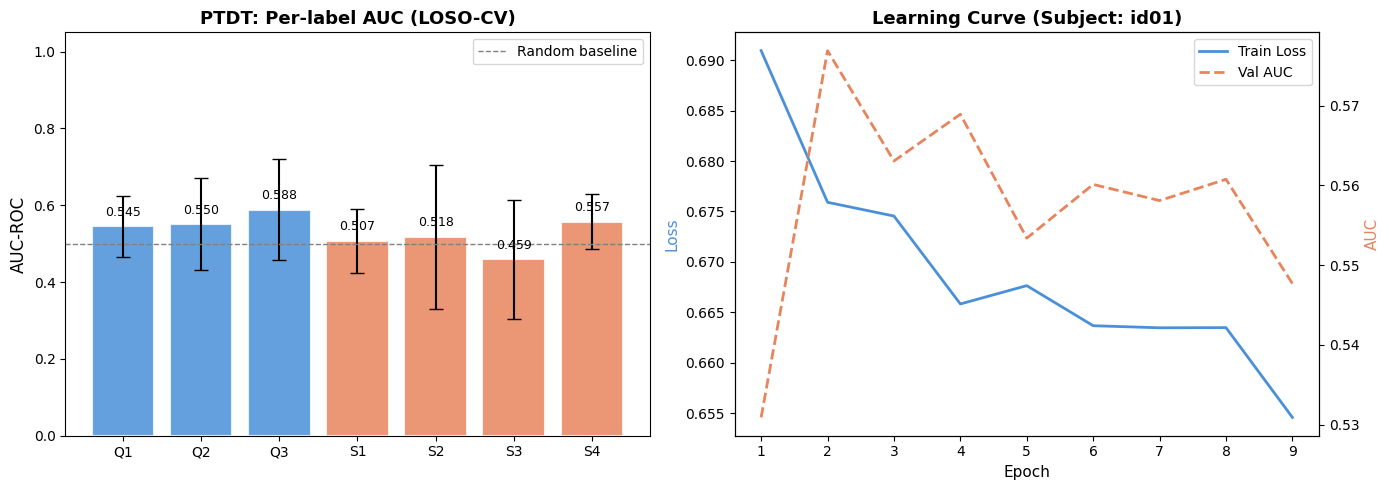

✅ 결과 저장: /content/ptdt_results.png


In [ ]:
# ─── 시각화 1: 레이블별 AUC ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC 막대 차트
ax = axes[0]
lbls = [l for l in available_labels if summary[l]['auc']]
aucs = [np.mean(summary[l]['auc']) for l in lbls]
stds = [np.std(summary[l]['auc'])  for l in lbls]
colors = ['#4A90D9' if l.startswith('Q') else '#E8845C' for l in lbls]

bars = ax.bar(lbls, aucs, yerr=stds, capsize=5,
              color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random baseline')
ax.set_ylim(0, 1.05)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('PTDT: Per-label AUC (LOSO-CV)', fontsize=13, fontweight='bold')
ax.legend()
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# 학습 곡선 (첫 번째 피험자)
ax2 = axes[1]
first_subj = list(loso_results.keys())[0]
hist = loso_results[first_subj]['history']
epochs_range = range(1, len(hist['train_loss'])+1)

ax2_twin = ax2.twinx()
l1, = ax2.plot(epochs_range, hist['train_loss'], '#4A90D9',
               linewidth=2, label='Train Loss')
l2, = ax2_twin.plot(epochs_range, hist['val_auc'], '#E8845C',
                    linewidth=2, linestyle='--', label='Val AUC')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Loss', color='#4A90D9', fontsize=11)
ax2_twin.set_ylabel('AUC', color='#E8845C', fontsize=11)
ax2.set_title(f'Learning Curve (Subject: {first_subj})', fontsize=13, fontweight='bold')
ax2.legend(handles=[l1, l2], loc='upper right')

plt.tight_layout()
plt.savefig('/content/ptdt_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 결과 저장: /content/ptdt_results.png')

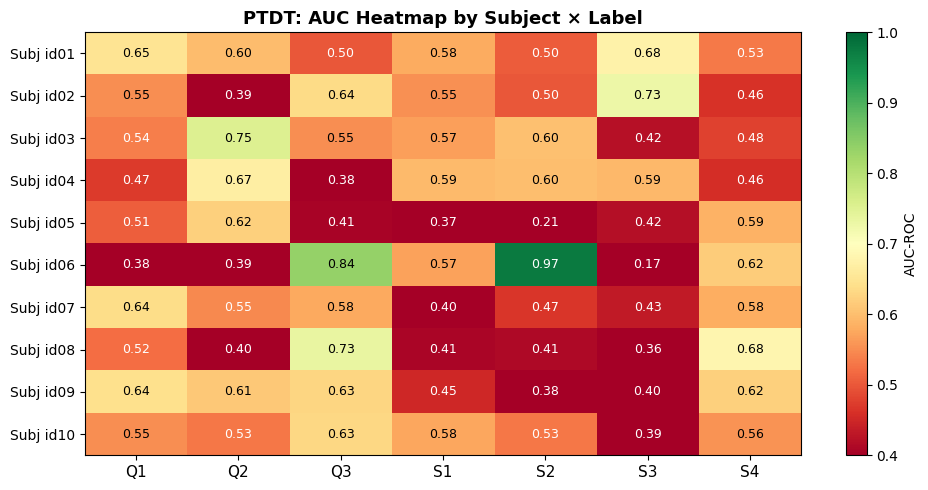

In [ ]:
# ─── 시각화 2: 피험자별 성능 히트맵 ──────────────────────
import matplotlib.colors as mcolors

subj_auc_matrix = []
subj_list = list(loso_results.keys())
lbl_list  = [l for l in available_labels if summary[l]['auc']]

for subj in subj_list:
    row = []
    for lbl in lbl_list:
        auc_val = loso_results[subj]['metrics'].get(lbl, {}).get('auc', 0.5)
        row.append(auc_val)
    subj_auc_matrix.append(row)

mat = np.array(subj_auc_matrix)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(mat, cmap='RdYlGn', vmin=0.4, vmax=1.0, aspect='auto')
plt.colorbar(im, ax=ax, label='AUC-ROC')

ax.set_xticks(range(len(lbl_list)))
ax.set_xticklabels(lbl_list, fontsize=11)
ax.set_yticks(range(len(subj_list)))
ax.set_yticklabels([f'Subj {s}' for s in subj_list], fontsize=10)
ax.set_title('PTDT: AUC Heatmap by Subject × Label', fontsize=13, fontweight='bold')

# 수치 표기
for i in range(len(subj_list)):
    for j in range(len(lbl_list)):
        text_color = 'white' if mat[i,j] < 0.55 or mat[i,j] > 0.85 else 'black'
        ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                fontsize=9, color=text_color)

plt.tight_layout()
plt.savefig('/content/ptdt_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. 모델 저장 및 예측 함수

In [ ]:
# ─── 전체 데이터로 최종 모델 재학습 ──────────────────────
print('🔄 전체 데이터로 최종 모델 재학습...')

full_ds = LifelogDataset(
    full_dev_df, all_feat_cols, available_labels, CONFIG['seq_len']
)
full_loader = DataLoader(full_ds, batch_size=CONFIG['batch_size'],
                         shuffle=True, drop_last=False)

final_model = PTDTransformer(
    n_features=N_FEATURES, n_labels=N_LABELS,
    d_model=CONFIG['d_model'], n_heads=CONFIG['n_heads'],
    n_layers=CONFIG['n_layers'], d_ff=CONFIG['d_ff'],
    dropout=0.05, seq_len=CONFIG['seq_len']  # dropout 낮춤
).to(device)

optimizer = torch.optim.AdamW(final_model.parameters(),
                               lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
criterion = nn.BCEWithLogitsLoss()

for epoch in range(1, CONFIG['epochs'] + 1):
    loss = train_one_epoch(final_model, full_loader, optimizer, criterion, device)
    if epoch % 10 == 0:
        print(f'  Epoch {epoch:3d}/{CONFIG["epochs"]} | Loss: {loss:.4f}')

# 저장
torch.save({
    'model_state': final_model.state_dict(),
    'config': CONFIG,
    'n_features': N_FEATURES,
    'n_labels': N_LABELS,
    'feat_cols': all_feat_cols,
    'label_cols': available_labels,
}, '/content/ptdt_model.pth')

print('✅ 모델 저장: /content/ptdt_model.pth')

🔄 전체 데이터로 최종 모델 재학습...
  Dataset: 380개 샘플 (subject=10명, seq_len=7)
  Epoch  10/30 | Loss: 0.6488
  Epoch  20/30 | Loss: 0.5676
  Epoch  30/30 | Loss: 0.4813
✅ 모델 저장: /content/ptdt_model.pth


In [ ]:
# ─── 추론 함수 ────────────────────────────────────────────

def predict_sleep_metrics(model, subject_history_df, feat_cols,
                          seq_len=SEQ_LEN, device=device):
    """
    새로운 피험자의 최근 seq_len일 데이터로 수면 지표 예측

    Args:
        model              : 학습된 PTDTransformer
        subject_history_df : 해당 피험자의 일별 피처 DataFrame (최소 seq_len+1행)
        feat_cols          : 피처 컬럼 리스트
        seq_len            : 입력 시퀀스 길이

    Returns:
        dict: {label: probability}
    """
    model.eval()

    df = subject_history_df.sort_values('date').tail(seq_len)

    if len(df) < seq_len:
        print(f'⚠️  {len(df)}일 데이터만 있습니다 (필요: {seq_len}일). 패딩 적용')
        pad_len = seq_len - len(df)
        pad_df = pd.DataFrame(0, index=range(pad_len), columns=df.columns)
        df = pd.concat([pad_df, df], ignore_index=True)

    # 피처 추출
    avail_cols = [c for c in feat_cols if c in df.columns]
    x = df[avail_cols].values.astype(np.float32)
    x = np.nan_to_num(x, nan=0.0)
    x = np.clip(x, -10, 10)

    # 누락 컬럼 처리
    if len(avail_cols) < len(feat_cols):
        full_x = np.zeros((seq_len, len(feat_cols)), dtype=np.float32)
        for i, col in enumerate(feat_cols):
            if col in avail_cols:
                full_x[:, i] = x[:, avail_cols.index(col)]
        x = full_x

    x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    result = {lbl: float(probs[i]) for i, lbl in enumerate(available_labels)}

    print('📊 예측 결과 (확률값 > 0.5 → 긍정적 결과):')
    for lbl, prob in result.items():
        icon = '✅' if prob >= 0.5 else '⚠️ '
        bar = '█' * int(prob * 20) + '░' * (20 - int(prob * 20))
        print(f'  {icon} {lbl}: [{bar}] {prob:.3f}')

    return result


# 테스트 예측
print('=== 예측 테스트 ===')
test_subject = all_subjects[0]
test_data    = full_dev_df[full_dev_df['subject_id'] == test_subject]
predict_sleep_metrics(final_model, test_data, all_feat_cols)

=== 예측 테스트 ===
📊 예측 결과 (확률값 > 0.5 → 긍정적 결과):
  ✅ Q1: [█████████████░░░░░░░] 0.690
  ✅ Q2: [█████████████████░░░] 0.857
  ✅ Q3: [████████████████░░░░] 0.833
  ✅ S1: [█████████████░░░░░░░] 0.662
  ✅ S2: [██████████████░░░░░░] 0.724
  ✅ S3: [███████████░░░░░░░░░] 0.593
  ✅ S4: [█████████████████░░░] 0.875


{'Q1': 0.6901328563690186,
 'Q2': 0.8573904633522034,
 'Q3': 0.8332579731941223,
 'S1': 0.6616238951683044,
 'S2': 0.7244325280189514,
 'S3': 0.5927713513374329,
 'S4': 0.8753856420516968}

## 12. 개선 방향 및 실험 가이드

---

### 🔧 튜닝 포인트

| 설정 | 현재값 | 실험 범위 | 효과 |
|------|--------|-----------|------|
| `SEQ_LEN` | 7 | 3, 5, 7, 14 | 과거 며칠이 예측에 유효한지 |
| `ROLLING_WINDOW` | 7 | 5, 7, 14, 21 | 개인 baseline 안정성 |
| `d_model` | 64 | 32, 64, 128 | 모델 용량 |
| `n_layers` | 2 | 1, 2, 3 | 표현 깊이 |
| `dropout` | 0.1 | 0.0–0.3 | 정규화 강도 |
| `lr` | 1e-3 | 5e-4, 1e-3, 3e-3 | 수렴 속도 |

### 🚀 성능 향상 아이디어

1. **센서별 토큰화**: 각 센서를 별도 토큰으로 처리 후 Cross-sensor Attention
2. **주기 임베딩**: 요일(0~6), 월(1~12)을 사인/코사인 임베딩으로 추가
3. **Focal Loss**: 레이블 불균형 대응 (`alpha`, `gamma` 파라미터)
4. **Test-Time Adaptation**: 테스트 피험자의 초반 데이터로 개인화 fine-tuning
5. **Ensemble**: PTDT + LightGBM + LSTM 앙상블

### 📝 대회 제출 형식
```python
submission = pd.DataFrame({
    'subject_id': [...],
    'date': [...],
    'Q1': [...],  'Q2': [...],  'Q3': [...],
    'S1': [...],  'S2': [...],  'S3': [...],  'S4': [...]
})
submission.to_csv('submission.csv', index=False)
```